# FMitF C-Edge Verification Time Investigation

## Two-stage workflow

**Stage 1: Generation** — `RUN_GENERATION = True` to create transact files, compile, and collect JSONs. `False` skips generation and reads existing output.

**Stage 2: Analysis** — Always reads from disk. Figures saved as PDF + displayed inline.

## Theme: What drives verification time?

1. Boogie file length → verification time
2. DB operations (read/write/total) → verification time
3. Branch count → verification time
4. Verification result (Pass/Error) → time distribution

## 1. Setup, Parameters & Generation


In [1]:
import os
import sys
import json
import subprocess
import shutil
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from pathlib import Path

# Color palette (consistent across all figures)
PASS_COLOR  = '#61AC85'   # mygreen:  RGB(97,172,133)
ERROR_COLOR = '#E77C8E'   # myred:    RGB(231,124,142)
ORANGE      = '#FF9900'   # myorange: RGB(255,153,0)
BLUE        = '#619AC3'   # myblue:   RGB(97,154,195)
GRAY_LIGHT  = '#CCCCCC'   # light gray for backgrounds
POINT_ALPHA = 0.6
sns.set_theme(style='whitegrid', font_scale=1.0)

# Dynamic root detection (walk up from cwd for .git)
_p = Path.cwd().resolve()
ROOT = next((d for d in [_p] + list(_p.parents) if (d / '.git').exists()), _p)
BASE = ROOT / 'tmp' / 'factor_sweep'
(BASE / 'output').mkdir(parents=True, exist_ok=True)

# Generator path
GENERATOR = ROOT / 'examples' / 'gen_transact.py'

# ===== CONFIG (constant across all transact files) =====
CFG = {
    'num_transactions': 5,
    'tables_min': 2, 'fields_per_table': 5,
    'pk_arity_min': 1, 'pk_arity_max': 2,
    'hops_min': 1, 'hops_max': 10,
    'ops_min': 1, 'ops_max': 10,
    'hops_zipf_s': 2.0, 'hops_poisson_mean': 7.0,
    'op_read_p': 0.50, 'op_write_p': 0.20,
    'op_inc_dec_p': 0.10, 'op_logical_p': 0.20,
    'for_loop_iters_min': 1, 'for_loop_iters_max': 8,
    'if_body_min_ops': 1, 'if_body_max_ops': 8,
    'for_loop_prob': 0.2, 'if_prob': 0.3,
    'if_else_prob': 0.3, 'continuation_prob': 0.3,
    'seed': 42385932,
}

# ===== FACTORS TO SWEEP (one per file, rest constant) =====
# Each factor is swept across these values; all other params stay at CFG defaults
FACTORS = {
    'txn_count':              [2, 5, 10],
    'hops_max':               [2, 3, 5, 7, 10],
    'for_loop_prob':          [0.0, 0.1, 0.25, 0.5, 0.75, 0.9],
    'if_prob':                [0.0, 0.1, 0.25, 0.5, 0.75, 0.9],
    'ops_max':                [1, 5, 10, 15, 20, 25, 30, 35, 40],
    'op_write_p':             [0.10, 0.20, 0.35, 0.50],
    'if_else_prob':           [0.0, 0.25, 0.5, 0.75],
    'if_body_max_ops':        [1, 5, 10, 15],
    'for_loop_iters_max':     [1, 3, 5, 7, 9],
}

# ===== GENERATION FLAGS =====
RUN_GENERATION = True   # True: delete old output & regenerate all; False: skip
DELETE_OLD = True       # Only meaningful if RUN_GENERATION=True

print('ROOT = %s' % ROOT)
print('BASE = %s' % BASE)
print('Generator: %s' % GENERATOR)
print('Factors to sweep:')
for f, vs in FACTORS.items():
    print('  %-15s: %s' % (f, vs))
print('RUN_GENERATION = %s' % RUN_GENERATION)



ROOT = /scratch/yanjunc6/FMitF_rs
BASE = /scratch/yanjunc6/FMitF_rs/tmp/factor_sweep
Generator: /scratch/yanjunc6/FMitF_rs/examples/gen_transact.py
Factors to sweep:
  txn_count      : [2, 5, 10]
  hops_max       : [2, 3, 5, 7, 10]
  for_loop_prob  : [0.0, 0.1, 0.25, 0.5, 0.75, 0.9]
  if_prob        : [0.0, 0.1, 0.25, 0.5, 0.75, 0.9]
  ops_max        : [1, 5, 10, 15, 20, 25, 30, 35, 40]
  op_write_p     : [0.1, 0.2, 0.35, 0.5]
  if_else_prob   : [0.0, 0.25, 0.5, 0.75]
  if_body_max_ops: [1, 5, 10, 15]
  for_loop_iters_max: [1, 3, 5, 7, 9]
RUN_GENERATION = True


## 2. Filename Encoding

Compact encoding: `t{N}h{M}f{L}i{P}-s42.transact`
Each transact varies one factor (the encoded value); all others use CFG defaults.

In [2]:
# ===== Short name generator =====

def short_name(factor, value):
    """Generate compact filename with all factor tags.
    
    Exactly one factor takes its swept value; others use CFG defaults.
    Format: t{N}h{M}f{L}i{P}o{O}w{W}e{E}b{B}r{R}-s42.transact
    """
    # (tag_char, CFG_key, formatter)
    FM = {
        'txn_count':          ('t', 'num_transactions',  lambda v: '%d' % int(v)),
        'hops_max':           ('h', 'hops_max',          lambda v: '%d' % int(v)),
        'for_loop_prob':      ('f', 'for_loop_prob',     lambda v: '%.2g' % v),
        'if_prob':            ('i', 'if_prob',           lambda v: '%.2g' % v),
        'ops_max':            ('o', 'ops_max',           lambda v: '%d' % int(v)),
        'op_write_p':         ('w', 'op_write_p',        lambda v: '%.2g' % v),
        'if_else_prob':       ('e', 'if_else_prob',      lambda v: '%.2g' % v),
        'if_body_max_ops':    ('b', 'if_body_max_ops',   lambda v: '%d' % int(v)),
        'for_loop_iters_max': ('r', 'for_loop_iters_max', lambda v: '%d' % int(v)),
    }
    tags = []
    for fkey, (tc, ck, fmt_fn) in FM.items():
        v = value if factor == fkey else CFG.get(ck, 0)
        tags.append('%s%s' % (tc, fmt_fn(v)))
    return '-'.join(tags) + '-s42.transact'


# ===== Parse short name back to factors =====

def parse_short(fname):
    """Extract all factors from compact filename."""
    mapping = {
        't': 'txn_count',
        'h': 'hops_max',
        'f': 'for_loop_prob',
        'i': 'if_prob',
        'o': 'ops_max',
        'w': 'op_write_p',
        'e': 'if_else_prob',
        'b': 'if_body_max_ops',
        'r': 'for_loop_iters_max',
    }
    result = {}
    clean = fname.replace('.transact', '').replace('-s42', '')
    i = 0
    while i < len(clean):
        if clean[i] in mapping:
            k = mapping[clean[i]]
            j = i + 1
            while j < len(clean) and clean[j] not in mapping:
                j += 1
            if j > i + 1:
                raw = clean[i+1:j].strip('-').strip('.')
                try:
                    val = float(raw)
                except ValueError:
                    val = raw
                if isinstance(val, float) and val == int(val):
                    val = int(val)
                result[k] = val
            i = j
        else:
            i += 1
    return result


# Test all 9 factors
for f, vs in FACTORS.items():
    for v in vs[:2]:
        name = short_name(f, v)
        parsed = parse_short(name)
        assert parsed.get(f) == v, 'Mismatch: %s → %s (expected %s=%s)' % (
            name, parsed, f, v)
print('Name encoding/decoding verified for all 9 factors.')



Name encoding/decoding verified for all 9 factors.


## 3. Generation Pipeline

For each factor-value pair: generate `.transact`, compile with FMitF, collect `data.json`.

In [3]:
# ===== Helper: generate one transact file =====

def generate_transact(factor, value):
    """Generate a .transact file with the given factor swept."""
    fname = short_name(factor, value)
    out = BASE / 'input' / fname
    args = ['python3', str(GENERATOR), '--seed', '42']
    for k, v in CFG.items():
        args += ['--' + k.replace('_', '-'), str(v)]
    # Override the factor being swept
    cli = factor.replace('_', '-')
    if cli == 'txn-count':
        cli = 'num-transactions'
    args += ['--' + cli, str(value)]
    args += ['--out', str(out)]
    r = subprocess.run(args, capture_output=True, text=True)
    if r.returncode != 0:
        print('  [GEN ERR] %s: %s' % (fname, r.stderr[:200]))
    return out

# ===== Helper: compile one transact file =====

def compile_transact(fname):
    """Compile a .transact file with FMitF compiler. Returns (out_dir, data.json) or None."""
    tpath = BASE / 'input' / fname
    out_dir = BASE / 'output' / fname.replace('.transact', '')
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    args = [
        'cargo', 'run', '--release', '--',
        str(tpath), str(out_dir), '--clear-cache', '--disable-split'
    ]
    try:
        r = subprocess.run(args, capture_output=True, text=True,
                          timeout=300, cwd=str(ROOT))
    except subprocess.TimeoutExpired:
        print('  [TIMEOUT] %s' % fname)
        return None
    dj = out_dir / 'data.json'
    if dj.exists() and dj.stat().st_size > 100:
        print('  [OK] %s (%.0f KB)' % (fname, dj.stat().st_size / 1024))
        return out_dir, dj
    print('  [FAIL] %s' % fname)
    return None

# ===== Main generation loop =====

all_file_summaries = []
all_cedge_records = []

if RUN_GENERATION:
    if DELETE_OLD:
        # Delete old output and input
        out_dir = BASE / 'output'
        in_dir = BASE / 'input'
        for d in [out_dir, in_dir]:
            if d.exists():
                shutil.rmtree(d)
        (BASE / 'input').mkdir(parents=True, exist_ok=True)
        (BASE / 'output').mkdir(exist_ok=True)
        print('Old output deleted.')

    total = sum(len(vs) for vs in FACTORS.values())
    count = 0
    print('\nStarting generation: %d transact files' % total)
    print('=' * 60)

    for factor, values in FACTORS.items():
        print('\n--- %s ---' % factor)
        for value in values:
            fname = short_name(factor, value)

            # Generate
            tp = generate_transact(factor, value)
            if not tp.exists():
                print('  SKIP (gen failed): %s' % fname)
                continue

            # Compile
            result = compile_transact(fname)
            if not result:
                continue

            out_dir, dj = result
            count += 1

            # Collect data from JSON (raw field names, NO cedge_ prefix)
            with open(dj) as f:
                data = json.load(f)

            recs = []
            for edge in data.get('c_edge_verifications', []):
                rec = dict(edge)  # raw: duration_ms, result, branch_count, etc.
                rec['variant_name'] = fname  # which transact file
                recs.append(rec)

            summary = data.get('summary', {})
            n = len(recs)
            times = [r.get('duration_ms', 0) for r in recs]
            times = [t for t in times if isinstance(t, (int, float)) and t > 0]
            pass_count = sum(1 for r in recs if r.get('result') == 'Pass')
            errs = n - pass_count
            st = sorted(times) if times else [0]

            bcs = [r.get('branch_count', 0) or 0 for r in recs]
            loops = [r.get('has_loop', False) for r in recs]
            dr = [r.get('db_read_count', 0) or 0 for r in recs]
            dw = [r.get('db_write_count', 0) or 0 for r in recs]

            fs = {
                'factor': factor, 'value': value,
                'num_c_edges': n,
                'num_pass': pass_count, 'num_error': errs,
                'commutative_pct': 100.0 * pass_count / n if n else 0,
                'total_time_ms': sum(times),
                'avg_time_ms': sum(times) / len(times) if times else 0,
                'median_time_ms': st[len(st)//2] if st else 0,
                'max_time_ms': max(times) if times else 0,
                'avg_branch_count': sum(bcs) / n if n else 0,
                'max_branch_count': max(bcs) if bcs else 0,
                'pct_with_loop': sum(1 for l in loops if l) / n * 100 if n else 0,
                'sum_db_read': sum(dr), 'sum_db_write': sum(dw),
                'sc_c_edges': summary.get('sc_c_edges', 0),
                'function_count': summary.get('function_count', 0),
                'hop_count': summary.get('hop_count', 0),
            }
            all_file_summaries.append(fs)
            all_cedge_records.extend(recs)

    print('\n' + '=' * 60)
    print('Generation complete: %d/%d files compiled' % (count, total))

    # Save collected data
    with open(BASE / 'all_file_summaries.json', 'w') as f:
        json.dump(all_file_summaries, f)
    with open(BASE / 'all_cedge_records.json', 'w') as f:
        json.dump(all_cedge_records, f)
    print('Saved all_file_summaries.json and all_cedge_records.json')
else:
    print('\nRUN_GENERATION=False — skipping generation.\n')

print('Records in memory: %d c-edge, %d files' % (len(all_cedge_records), len(all_file_summaries)))

Old output deleted.

Starting generation: 46 transact files

--- txn_count ---
  [OK] t2-h10-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (5 KB)
  [OK] t5-h10-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (10 KB)
  [OK] t10-h10-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (8 KB)

--- hops_max ---
  [OK] t5-h2-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (10 KB)
  [OK] t5-h3-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (10 KB)
  [OK] t5-h5-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (10 KB)
  [OK] t5-h7-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (10 KB)
  [OK] t5-h10-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (10 KB)

--- for_loop_prob ---
  [OK] t5-h10-f0-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (6 KB)
  [OK] t5-h10-f0.1-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (6 KB)
  [OK] t5-h10-f0.25-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (10 KB)
  [OK] t5-h10-f0.5-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (6 KB)
  [OK] t5-h10-f0.75-i0.3-o10-w0.2-e0.3-b8-r8-s42.transact (9 KB)
  [OK] t5-h10-f0.9-i0.3-o10-w0.2-e0.3-b8-r8-

## 4. Load Data from Disk

Always reads from `all_cedge_records.json` — never hardcodes. Works after generation or with pre-existing data.

In [4]:
# Always read from disk (may already be populated by cell 3)
ceg = BASE / 'all_cedge_records.json'
cfm = BASE / 'all_file_summaries.json'

if not all_cedge_records and ceg.exists():
    with open(ceg) as f:
        all_cedge_records = json.load(f)
if not all_file_summaries and cfm.exists():
    with open(cfm) as f:
        all_file_summaries = json.load(f)

df_cedge = pd.DataFrame(all_cedge_records)
df_file = pd.DataFrame(all_file_summaries)

# Convert numeric columns
num_cols = [
    'duration_ms', 'boogie_file_len', 'real_procedure_len',
    'branch_count', 'db_read_count', 'db_write_count',
    'source_function_id', 'target_function_id',
]
for c in num_cols:
    if c in df_cedge.columns:
        df_cedge[c] = pd.to_numeric(df_cedge[c], errors='coerce')

# Derived columns
if 'db_read_count' in df_cedge.columns and 'db_write_count' in df_cedge.columns:
    df_cedge['db_total_ops'] = (
        df_cedge['db_read_count'].fillna(0) + df_cedge['db_write_count'].fillna(0)
    )
else:
    df_cedge['db_total_ops'] = 0

print('Loaded %d c-edge records from %d transact files' % (
    len(df_cedge), len(df_file)))

# Show which files are available
output_dirs = sorted([d.name for d in (BASE / 'output').iterdir() if d.is_dir()])
print('\nOutput directories: %d' % len(output_dirs))
for d in output_dirs[:5]:
    print('  %s' % d)
if len(output_dirs) > 5:
    print('  ... and %d more' % (len(output_dirs) - 5))

Loaded 698 c-edge records from 46 transact files

Output directories: 43
  t10-h10-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42
  t2-h10-f0.2-i0.3-o10-w0.2-e0.3-b8-r8-s42
  t5-h10-f0-i0.3-o10-w0.2-e0.3-b8-r8-s42
  t5-h10-f0.1-i0.3-o10-w0.2-e0.3-b8-r8-s42
  t5-h10-f0.2-i0-o10-w0.2-e0.3-b8-r8-s42
  ... and 38 more


## 5. Descriptive Statistics

In [5]:
# Summary table
summary_cols = [
    'duration_ms', 'boogie_file_len', 'real_procedure_len',
    'branch_count', 'db_read_count', 'db_write_count', 'db_total_ops'
]

print('=' * 80)
print('DESCRIBE: Key numeric fields (all c-edges)')
print('=' * 80)
print(df_cedge[summary_cols].describe().round(2).to_string())

print('\n--- Result breakdown ---')
result_counts = df_cedge['result'].value_counts()
for r, cnt in result_counts.items():
    pct = 100 * cnt / len(df_cedge)
    avg_t = df_cedge[df_cedge['result'] == r]['duration_ms'].mean()
    print('  %12s: %4d records (%5.1f%%), avg_time=%.1fms' % (r, cnt, pct, avg_t))

print('\n--- Spearman correlation matrix ---')
corr_cols = ['duration_ms', 'boogie_file_len', 'real_procedure_len',
             'branch_count', 'db_read_count', 'db_write_count', 'db_total_ops']
corr = df_cedge[corr_cols].corr()
print(corr.round(4).to_string())




DESCRIBE: Key numeric fields (all c-edges)
       duration_ms  boogie_file_len  real_procedure_len  branch_count  db_read_count  db_write_count  db_total_ops
count       698.00           698.00              698.00        698.00         698.00          698.00        698.00
mean       5150.74         15716.56             7968.94          1.65           4.66           16.98         21.64
std       10167.10          3260.18             3259.89          1.00           3.84           16.48         17.84
min         402.44          9927.00             2186.00          0.00           0.00            2.00          2.00
25%         611.49         14106.00             6365.00          1.00           2.00            6.00         12.00
50%         665.27         14833.00             6953.00          2.00           4.00           14.00         18.00
75%         948.22         17062.00             9321.00          2.00           7.00           22.75         28.00
max       31151.83         54729.00  

## Theme 1: Boogie File Length → Verification Time

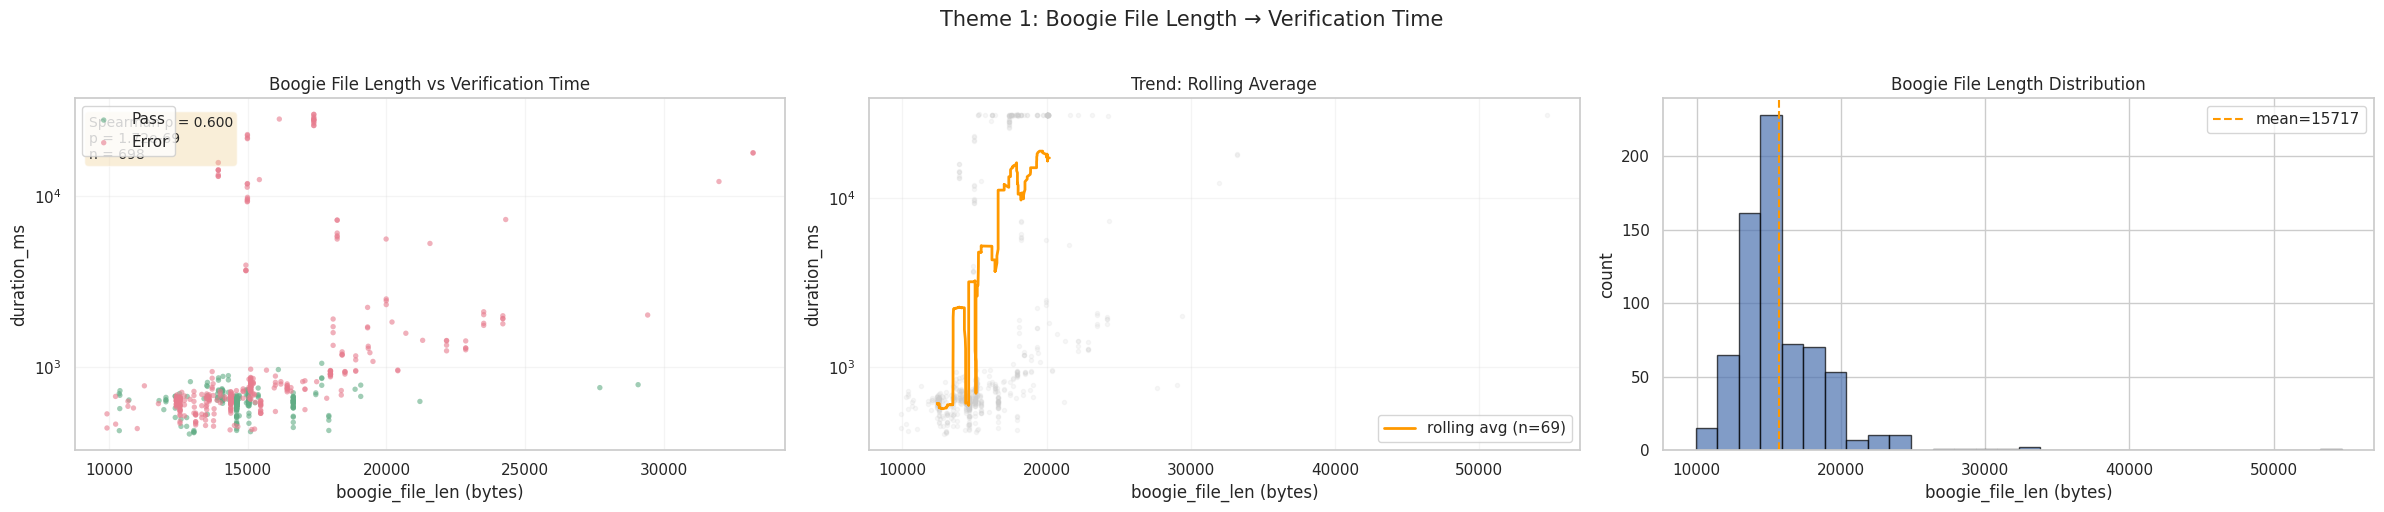

Saved /scratch/yanjunc6/FMitF_rs/tmp/factor_sweep/theme1_boogie_vs_time.pdf


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(24, 5))
x = df_cedge['boogie_file_len']
y = df_cedge['duration_ms']
mask_pass = df_cedge['result'] == 'Pass'
mask_error = df_cedge['result'] == 'Error'

# Panel 1a: Scatter colored by result
axes[0].scatter(x[mask_pass], y[mask_pass], c=PASS_COLOR, alpha=POINT_ALPHA, s=15, edgecolors='none', label='Pass')
axes[0].scatter(x[mask_error], y[mask_error], c=ERROR_COLOR, alpha=POINT_ALPHA, s=15, edgecolors='none', label='Error')
axes[0].set_xlabel('boogie_file_len (bytes)')
axes[0].set_ylabel('duration_ms')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.2)
axes[0].set_title('Boogie File Length vs Verification Time')
axes[0].legend(loc='upper left')

# Panel 1b: Rolling average trend
sort_idx = np.argsort(x.values)
x_sorted = x.values[sort_idx]
y_sorted = y.values[sort_idx]
window = max(1, len(df_cedge) // 10)
rolling_mean = pd.Series(y_sorted).rolling(window=window, center=True).mean().values
axes[1].plot(x_sorted, y_sorted, 'o', alpha=0.15, markersize=3, color=GRAY_LIGHT)
axes[1].plot(x_sorted, rolling_mean, '-', color=ORANGE, linewidth=2, label='rolling avg (n=%d)' % window)
axes[1].set_xlabel('boogie_file_len (bytes)')
axes[1].set_ylabel('duration_ms')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.2)
axes[1].set_title('Trend: Rolling Average')
axes[1].legend()

# Panel 1c: Distribution
axes[2].hist(x.dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('boogie_file_len (bytes)')
axes[2].set_ylabel('count')
axes[2].set_title('Boogie File Length Distribution')
axes[2].axvline(x.dropna().mean(), color=ORANGE, linestyle='--', label='mean=%.0f' % x.dropna().mean())
axes[2].legend()

# Correlation annotation
rho, p = stats.spearmanr(x.dropna(), y.dropna())
axes[0].text(0.02, 0.95, 'Spearman ρ = %.3f\np = %.2e\nn = %d' % (rho, p, len(df_cedge)),
            transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Theme 1: Boogie File Length → Verification Time', fontsize=15, y=1.02)
fig.tight_layout()
out = BASE / 'theme1_boogie_vs_time.pdf'
fig.savefig(str(out), dpi=150, format='pdf')
plt.show()
print('Saved %s' % out)




## Theme 2: DB Operations → Verification Time

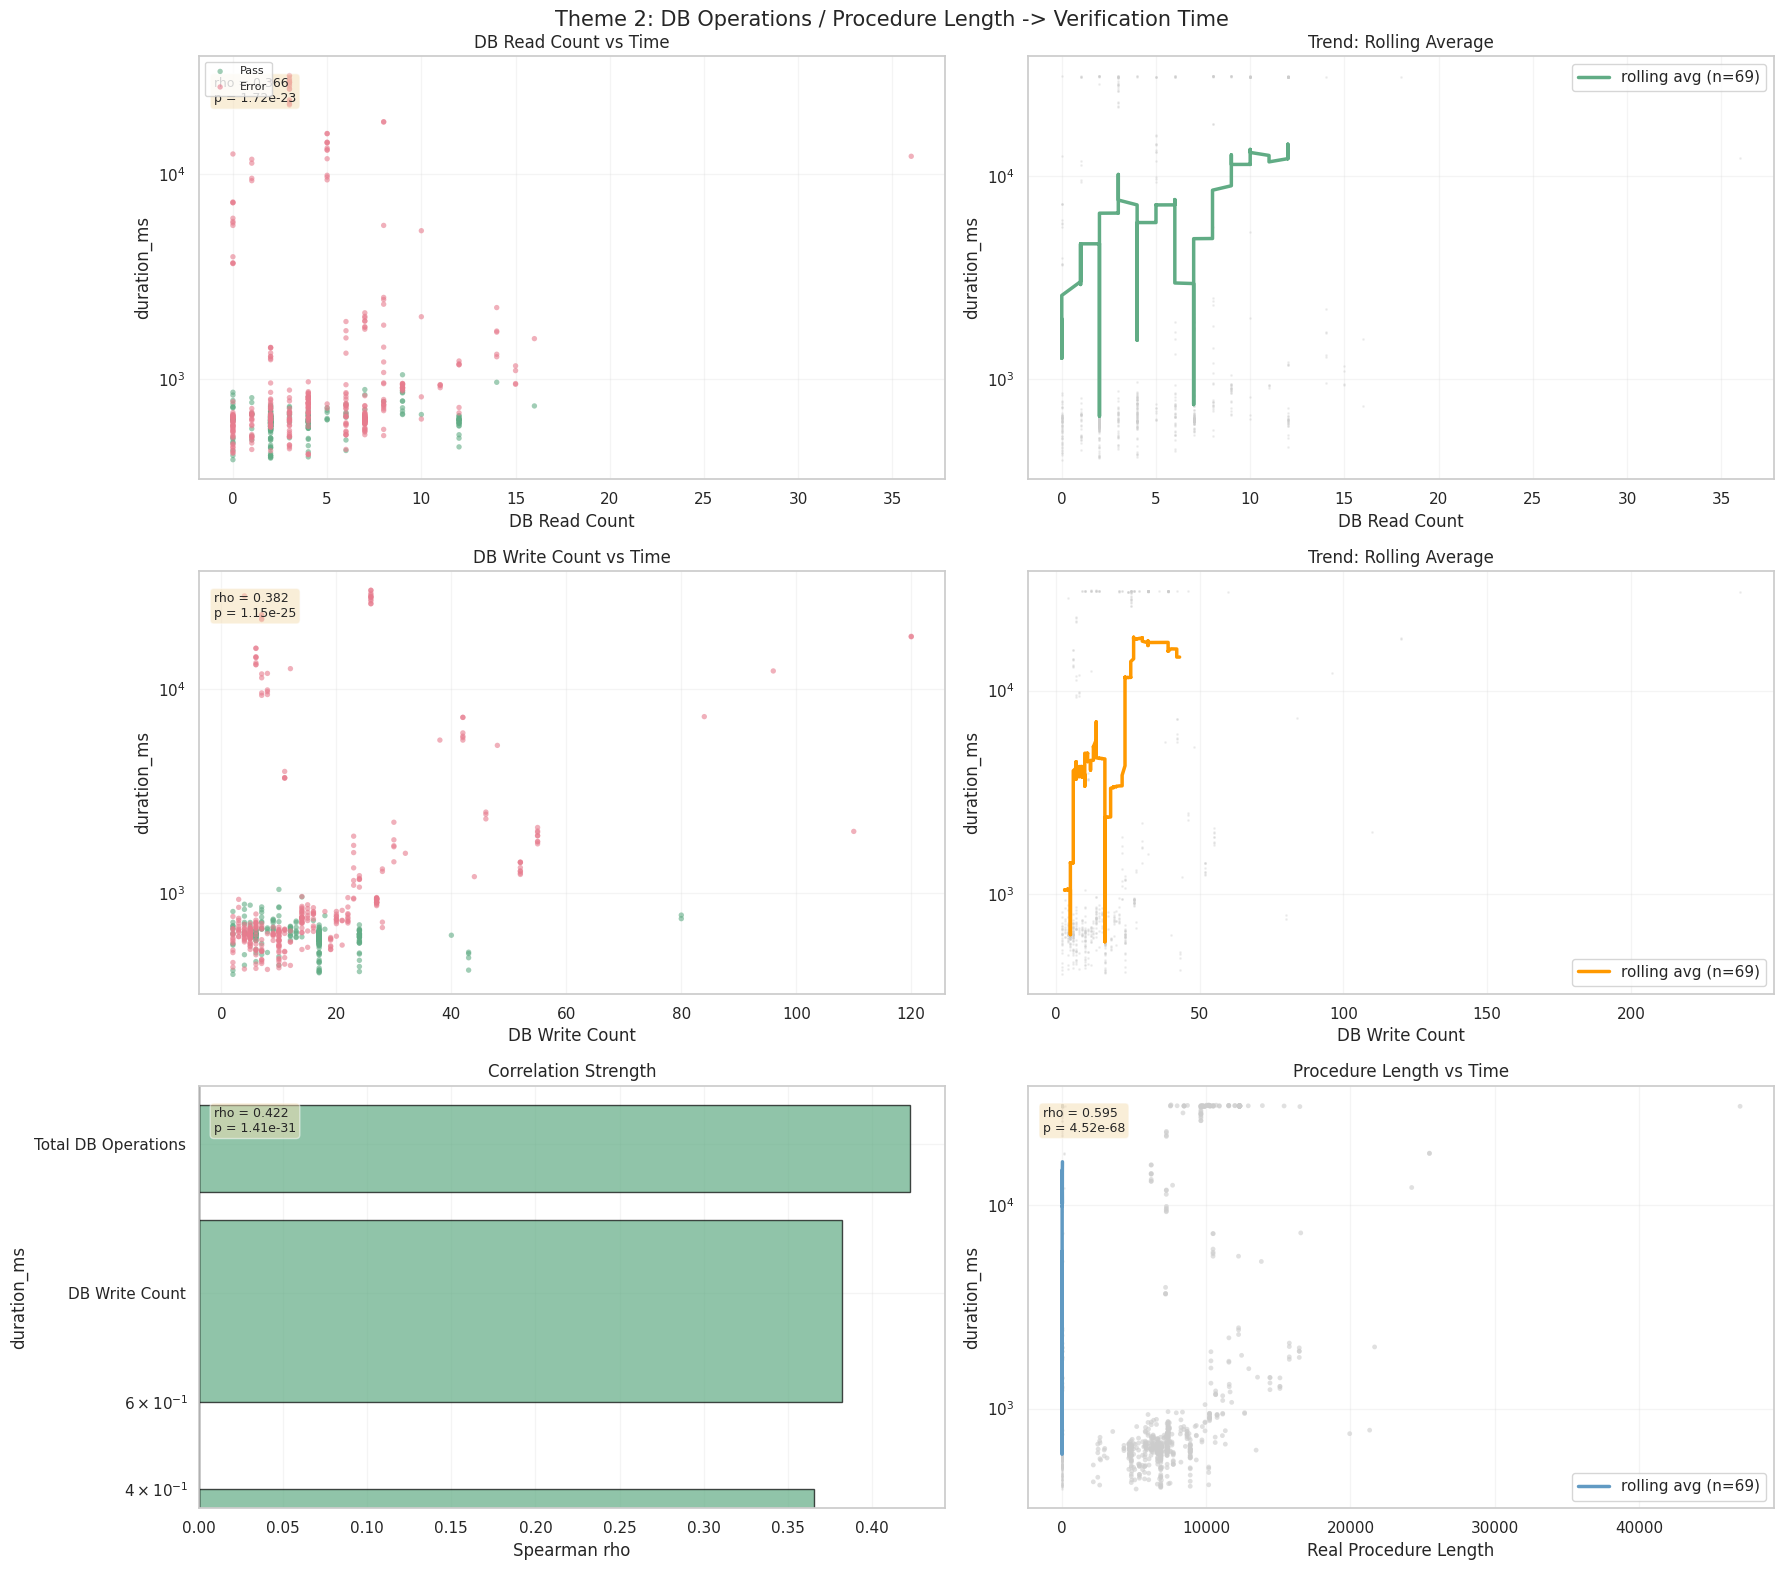

Saved /scratch/yanjunc6/FMitF_rs/tmp/factor_sweep/theme2_db_vs_time.pdf

Correlations:
  DB Read Count            : rho = 0.3655, p = 1.72e-23
  DB Write Count           : rho = 0.3820, p = 1.15e-25
  Total DB Operations      : rho = 0.4224, p = 1.41e-31


In [7]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# Variables: scatter (left) + rolling average (right)
db_vars = [
    ('db_read_count',  'DB Read Count'),
    ('db_write_count', 'DB Write Count'),
    ('db_total_ops',   'Total DB Operations'),
]
colors = [PASS_COLOR, ORANGE, BLUE]
correlations = {}

for row_idx, (var, label) in enumerate(db_vars):
    x = df_cedge[var]
    y = df_cedge['duration_ms']

    # Left: scatter colored by result
    mask_p = df_cedge['result'] == 'Pass'
    mask_e = df_cedge['result'] == 'Error'
    axes[row_idx, 0].scatter(x[mask_p], y[mask_p], c=PASS_COLOR,
                             alpha=POINT_ALPHA, s=15, edgecolors='none', label='Pass')
    axes[row_idx, 0].scatter(x[mask_e], y[mask_e], c=ERROR_COLOR,
                             alpha=POINT_ALPHA, s=15, edgecolors='none', label='Error')
    axes[row_idx, 0].set_xlabel(label)
    axes[row_idx, 0].set_ylabel('duration_ms')
    axes[row_idx, 0].set_yscale('log')
    axes[row_idx, 0].grid(True, alpha=0.2)
    axes[row_idx, 0].set_title(label + ' vs Time')
    if row_idx == 0:
        axes[row_idx, 0].legend(loc='upper left', fontsize=8)

    # Right: rolling average trend
    sort_idx = np.argsort(x.values)
    x_sorted = x.values[sort_idx]
    y_sorted = y.values[sort_idx]
    window = max(1, len(df_cedge) // 10)
    rolling_mean = pd.Series(y_sorted).rolling(window=window, center=True).mean().values

    axes[row_idx, 1].plot(x_sorted, y_sorted, '.', alpha=0.25, markersize=2, color=GRAY_LIGHT)
    axes[row_idx, 1].plot(x_sorted, rolling_mean, '-', color=colors[row_idx],
                          linewidth=2.5, label='rolling avg (n=%d)' % window)
    axes[row_idx, 1].set_xlabel(label)
    axes[row_idx, 1].set_ylabel('duration_ms')
    axes[row_idx, 1].set_yscale('log')
    axes[row_idx, 1].grid(True, alpha=0.2)
    axes[row_idx, 1].set_title('Trend: Rolling Average')
    axes[row_idx, 1].legend()

    # Correlation
    rho, p = stats.spearmanr(x.dropna(), y.dropna())
    correlations[label] = (rho, p)
    axes[row_idx, 0].text(0.02, 0.95, 'rho = %.3f\np = %.2e' % (rho, p),
                          transform=axes[row_idx, 0].transAxes, fontsize=9,
                          verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Bottom row: correlation bar chart (left) + procedure length scatter (right)
ax_bar = axes[2, 0]
labels = [c[1] for c in db_vars]
rhos = [c[0] for c in correlations.values()]
bar_colors = [PASS_COLOR if r > 0 else ERROR_COLOR for r in rhos]
bars = ax_bar.barh(labels, rhos, color=bar_colors, alpha=0.7, edgecolor='black')
ax_bar.axvline(x=0, color='black', linewidth=1)
ax_bar.set_xlabel('Spearman rho')
ax_bar.set_title('Correlation Strength')

dp = df_cedge['real_procedure_len']
yd = df_cedge['duration_ms']
valid = dp.notna() & yd.notna()
axes[2, 1].scatter(dp[valid], yd[valid], alpha=POINT_ALPHA, s=12,
                   color=GRAY_LIGHT, edgecolors='none')
rho_p, p_p = stats.spearmanr(dp.dropna(), yd.dropna())
axes[2, 1].set_xlabel('Real Procedure Length')
axes[2, 1].set_ylabel('duration_ms')
axes[2, 1].set_yscale('log')
axes[2, 1].grid(True, alpha=0.2)
axes[2, 1].set_title('Procedure Length vs Time')
axes[2, 1].text(0.02, 0.95, 'rho = %.3f\np = %.2e' % (rho_p, p_p),
                transform=axes[2, 1].transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Theme 2: DB Operations / Procedure Length -> Verification Time', fontsize=15, y=0.98)
fig.tight_layout()
out = BASE / 'theme2_db_vs_time.pdf'
fig.savefig(str(out), dpi=150, format='pdf')
plt.show()
print('Saved %s' % out)

print('\nCorrelations:')
for label, (rho, p) in correlations.items():
    print('  %-25s: rho = %.4f, p = %.2e' % (label, rho, p))



## Theme 3: Branch Count → Verification Time

/tmp/ipykernel_160860/578682114.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=branches['bc_group'].unique().astype(str), patch_artist=True, showfliers=False)


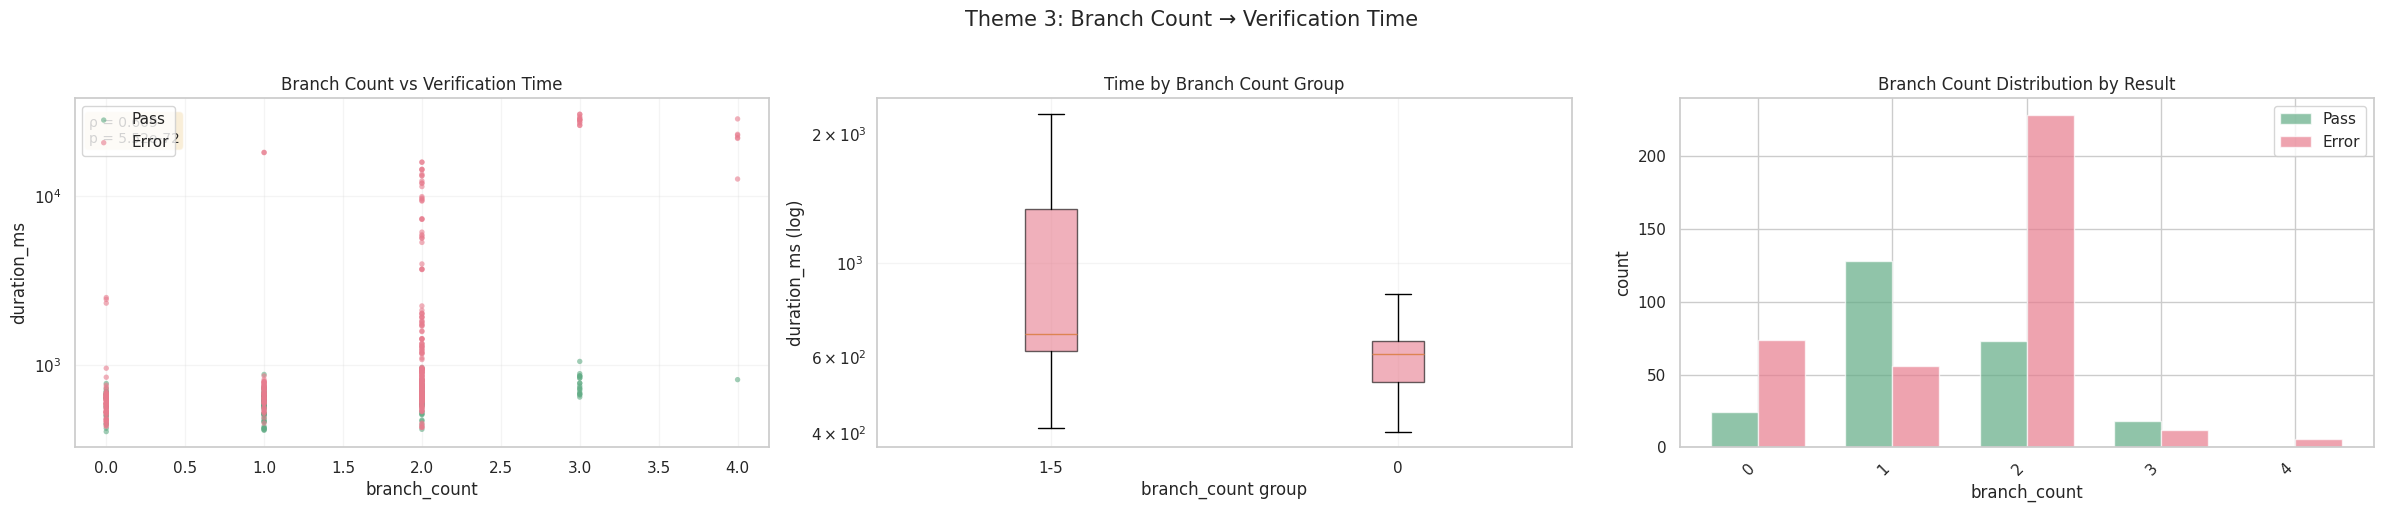

Saved /scratch/yanjunc6/FMitF_rs/tmp/factor_sweep/theme3_branch_vs_time.pdf


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(24, 5))
x = df_cedge['branch_count']
y = df_cedge['duration_ms']
mask_p = df_cedge['result'] == 'Pass'
mask_e = df_cedge['result'] == 'Error'

# Panel 3a: Scatter
axes[0].scatter(x[mask_p], y[mask_p], c=PASS_COLOR, alpha=POINT_ALPHA, s=15, edgecolors='none', label='Pass')
axes[0].scatter(x[mask_e], y[mask_e], c=ERROR_COLOR, alpha=POINT_ALPHA, s=15, edgecolors='none', label='Error')
axes[0].set_xlabel('branch_count')
axes[0].set_ylabel('duration_ms')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.2)
axes[0].set_title('Branch Count vs Verification Time')
axes[0].legend(loc='upper left')
rho, p = stats.spearmanr(x.dropna(), y.dropna())
axes[0].text(0.02, 0.95, 'ρ = %.3f\np = %.2e' % (rho, p), transform=axes[0].transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel 3b: Box plot by branch count groups
branches = df_cedge[['branch_count', 'duration_ms']].dropna()
branches['bc_group'] = pd.cut(branches['branch_count'], bins=[-1, 0, 5, 10, 50, float('inf')],
                               labels=['0', '1-5', '6-10', '11-50', '50+'])
box_data = [branches[branches['bc_group'] == g]['duration_ms'].values for g in branches['bc_group'].unique()]
bp = axes[1].boxplot(box_data, labels=branches['bc_group'].unique().astype(str), patch_artist=True, showfliers=False)
for patch, grp in zip(bp['boxes'], branches['bc_group'].unique()):
    grp_df = df_cedge[df_cedge['branch_count'].between(
        branches[branches['bc_group'] == grp]['branch_count'].min(),
        branches[branches['bc_group'] == grp]['branch_count'].max())]
    pass_cnt = (grp_df['result'] == 'Pass').sum()
    tot = pass_cnt + (grp_df['result'] == 'Error').sum()
    patch.set_facecolor(PASS_COLOR if pass_cnt / tot > 0.5 else ERROR_COLOR)
    patch.set_alpha(0.6)
axes[1].set_xlabel('branch_count group')
axes[1].set_ylabel('duration_ms (log)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.2)
axes[1].set_title('Time by Branch Count Group')

# Panel 3c: Histogram by result
# Side-by-side bar chart: Pass vs Error (same x-axis)
bc_unique = sorted(df_cedge['branch_count'].dropna().unique())
if len(bc_unique) > 8:
    bins = pd.cut(df_cedge['branch_count'], bins=8)
    all_cats = bins.dropna().unique().categories
    counts_p = df_cedge.loc[mask_p, 'branch_count'].apply(lambda v: bins.loc[v] if pd.notna(bins.loc[v]) else None).value_counts().reindex(all_cats, fill_value=0)
    counts_e = df_cedge.loc[mask_e, 'branch_count'].apply(lambda v: bins.loc[v] if pd.notna(bins.loc[v]) else None).value_counts().reindex(all_cats, fill_value=0)
    labels = [str(b) for b in all_cats]
else:
    counts_p = df_cedge.loc[mask_p, 'branch_count'].value_counts().sort_index()
    counts_e = df_cedge.loc[mask_e, 'branch_count'].value_counts().sort_index()
    all_labels = sorted(counts_p.index.union(counts_e.index))
    counts_p = counts_p.reindex(all_labels, fill_value=0)
    counts_e = counts_e.reindex(all_labels, fill_value=0)
    labels = [str(int(v)) for v in all_labels]

idx = np.arange(len(labels))
width = 0.35
axes[2].bar(idx - width/2, counts_p.values, width, color=PASS_COLOR, alpha=0.7, edgecolor='white', label='Pass')
axes[2].bar(idx + width/2, counts_e.values, width, color=ERROR_COLOR, alpha=0.7, edgecolor='white', label='Error')
axes[2].set_xticks(idx)
axes[2].set_xticklabels(labels, rotation=45, ha='right')
axes[2].set_xlabel('branch_count')
axes[2].set_ylabel('count')
axes[2].set_title('Branch Count Distribution by Result')
axes[2].legend()

fig.suptitle('Theme 3: Branch Count → Verification Time', fontsize=15, y=1.02)
fig.tight_layout()
out = BASE / 'theme3_branch_vs_time.pdf'
fig.savefig(str(out), dpi=150, format='pdf')
plt.show()
print('Saved %s' % out)





## Theme 4: Result (Pass/Error) → Time Distribution

/tmp/ipykernel_160860/4014467078.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(box_data_list,
/tmp/ipykernel_160860/4014467078.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Pass', 'Error'])


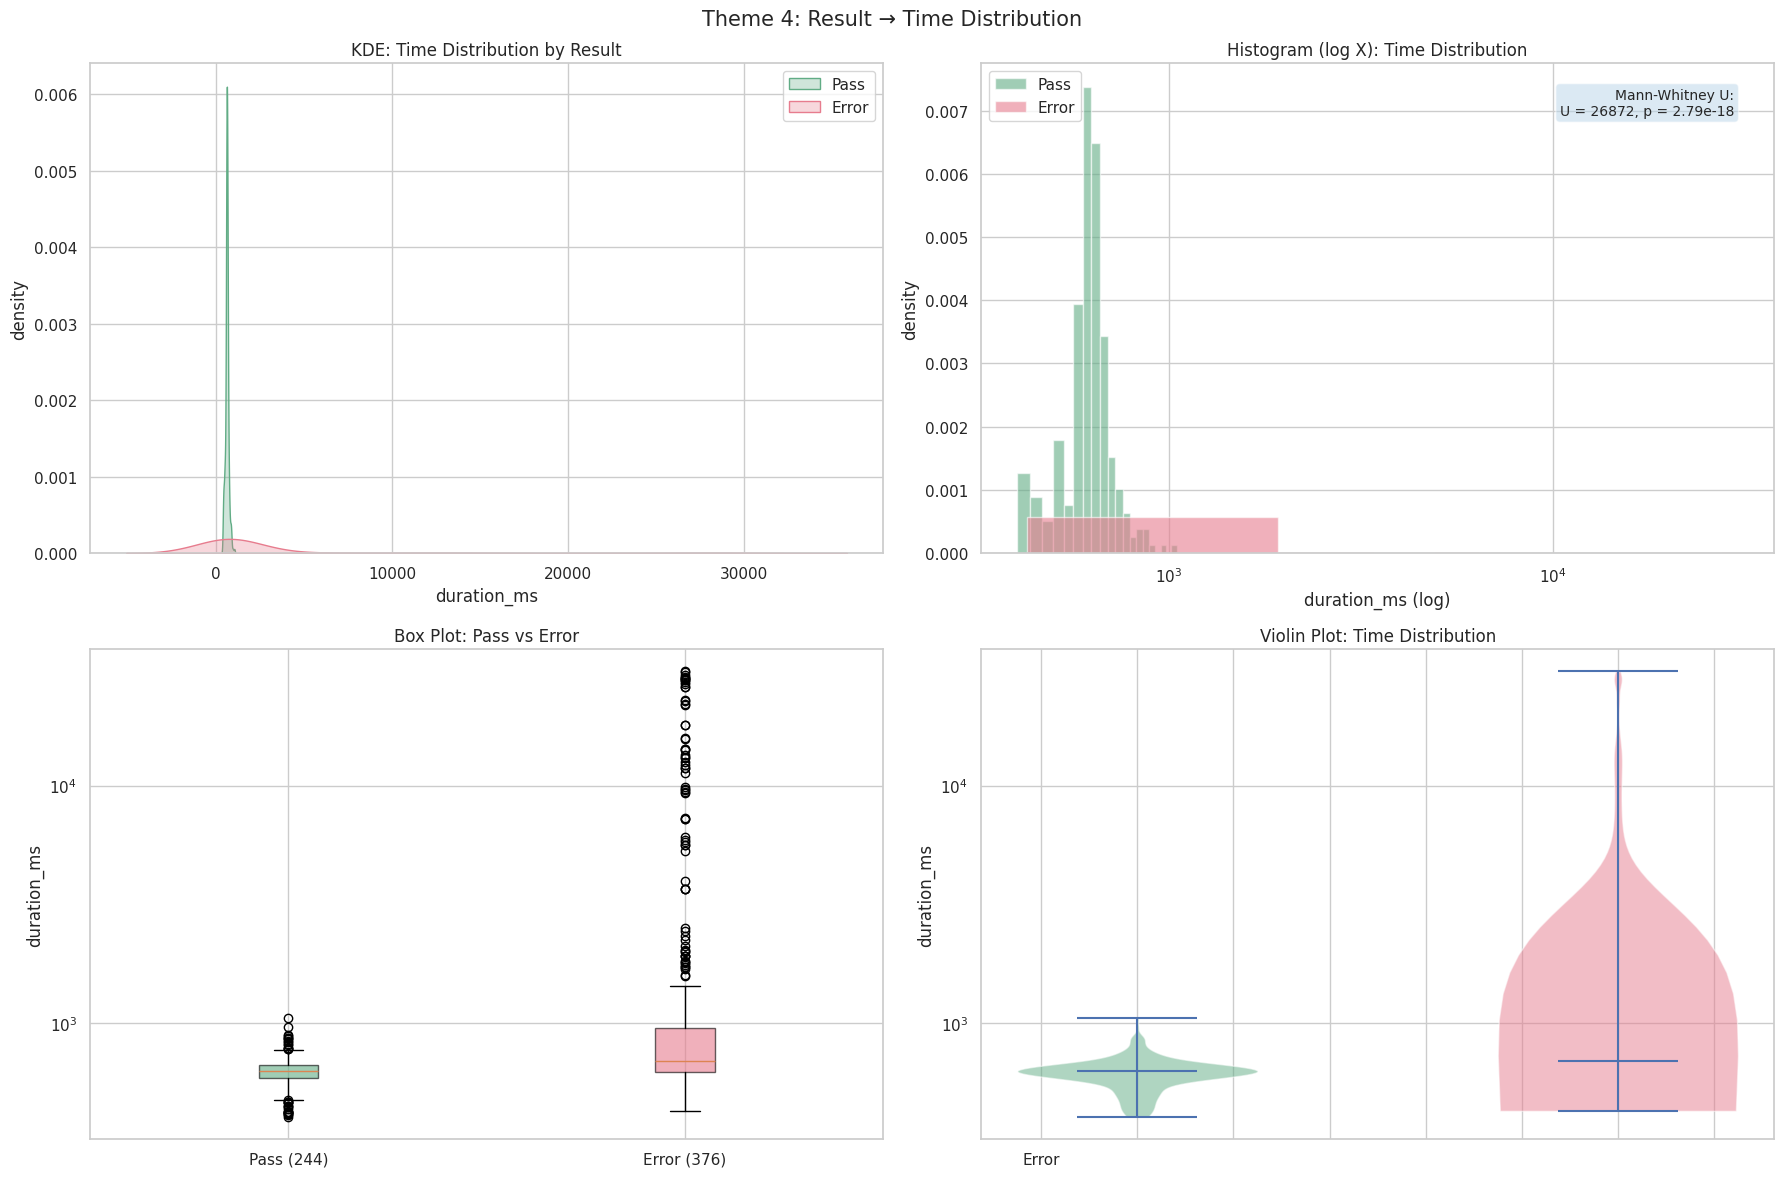

Saved /scratch/yanjunc6/FMitF_rs/tmp/factor_sweep/theme4_result_vs_time.pdf

Mann-Whitney U: U = 26872, p = 2.79e-18
Pass:  mean=624.0ms, median=624.4ms, n=244
Error: mean=2765.6ms, median=689.1ms, n=376


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
pass_df = df_cedge[df_cedge['result'] == 'Pass']['duration_ms'].dropna()
error_df = df_cedge[df_cedge['result'] == 'Error']['duration_ms'].dropna()

# Panel 4a: Overlaid KDE
sns.kdeplot(pass_df, ax=axes[0, 0], color=PASS_COLOR, label='Pass', fill=True, alpha=0.3)
sns.kdeplot(error_df, ax=axes[0, 0], color=ERROR_COLOR, label='Error', fill=True, alpha=0.3)
axes[0, 0].set_xlabel('duration_ms')
axes[0, 0].set_ylabel('density')
axes[0, 0].set_title('KDE: Time Distribution by Result')
axes[0, 0].legend()

# Panel 4b: Log-scale histogram
axes[0, 1].hist(pass_df, bins=20, alpha=0.6, color=PASS_COLOR, label='Pass', density=True)
axes[0, 1].hist(error_df, bins=20, alpha=0.6, color=ERROR_COLOR, label='Error', density=True)
axes[0, 1].set_xlabel('duration_ms (log)')
axes[0, 1].set_xscale('log')
axes[0, 1].set_ylabel('density')
axes[0, 1].set_title('Histogram (log X): Time Distribution')
axes[0, 1].legend()

# Panel 4c: Box plot
box_data_list = [pass_df.values, error_df.values]
bp = axes[1, 0].boxplot(box_data_list,
                        labels=['Pass (%d)' % len(pass_df), 'Error (%d)' % len(error_df)],
                        patch_artist=True)
bp['boxes'][0].set_facecolor(PASS_COLOR); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor(ERROR_COLOR); bp['boxes'][1].set_alpha(0.6)
axes[1, 0].set_ylabel('duration_ms')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Box Plot: Pass vs Error')

# Panel 4d: Violin plot
parts = axes[1, 1].violinplot([pass_df.values, error_df.values], showmeans=False, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PASS_COLOR if i == 0 else ERROR_COLOR)
    pc.set_alpha(0.5)
axes[1, 1].set_xticklabels(['Pass', 'Error'])
axes[1, 1].set_ylabel('duration_ms')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Violin Plot: Time Distribution')

# Mann-Whitney test annotation
stat_val, stat_p = stats.mannwhitneyu(pass_df, error_df, alternative='two-sided')
axes[0, 1].text(0.95, 0.95, 'Mann-Whitney U:\nU = %.0f, p = %.2e' % (stat_val, stat_p),
               transform=axes[0, 1].transAxes, ha='right', va='top', fontsize=10,
               bbox=dict(boxstyle='round', facecolor='#B8D4E8', alpha=0.5))

fig.suptitle('Theme 4: Result → Time Distribution', fontsize=15, y=0.98)
fig.tight_layout()
out = BASE / 'theme4_result_vs_time.pdf'
fig.savefig(str(out), dpi=150, format='pdf')
plt.show()
print('Saved %s' % out)
print('\nMann-Whitney U: U = %.0f, p = %.2e' % (stat_val, stat_p))
print('Pass:  mean=%.1fms, median=%.1fms, n=%d' % (pass_df.mean(), pass_df.median(), len(pass_df)))
print('Error: mean=%.1fms, median=%.1fms, n=%d' % (error_df.mean(), error_df.median(), len(error_df)))


## Summary of Figures

| File | Theme | Content |
|------|-------|--------|
| `theme1_boogie_vs_time.pdf` | Boogie file length | Scatter + rolling avg + distribution |
| `theme2_db_vs_time.pdf` | DB ops | 4-panel: reads, writes, total, procedure length |
| `theme3_branch_vs_time.pdf` | Branch count | Scatter + box groups + histogram |
| `theme4_result_vs_time.pdf` | Result vs time | KDE, histogram, box, violin plot |

> **green = Pass**, **red = Error**. Spearman ρ on each panel. Data exploratory — patterns to investigate.